<a href="https://colab.research.google.com/github/rafi145/Cloud_Computing/blob/main/tirgul4_1Cloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [7]:
# -*- coding: utf-8 -*-
"""Cars_DB.ipynb
.
Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1vX90dk7RUqXPNgH-kMnnTPhtwSaDCRUs
"""

url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3'

import requests
import pandas as pd
pd.set_option("display.max_columns", None)

response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)

data_df = pd.DataFrame(data['result']['records'])

data_df.head()

# Import necessary libraries
from ipywidgets import widgets, VBox, interact, Output
from IPython.display import display
output_area = Output()

# Create widgets
tozeret_nm_dropdown = widgets.Dropdown(
    options=[''] + sorted(data_df['tozeret_nm'].unique().tolist()),
    description='Tozeret:',
    style={'description_width': 'initial'}
)

kinuy_mishari_dropdown = widgets.Dropdown(
    options=[''],
    description='Kinuy Mishari:',
    style={'description_width': 'initial'}
)

# Function to update the second dropdown based on the selection of the first
def update_kinuy_mishari_options(change):
    if change['new']:  # Check if a valid option is selected
        filtered_values = data_df[data_df['tozeret_nm'] == change['new']]['kinuy_mishari'].unique()
        kinuy_mishari_dropdown.options = [''] + sorted(filtered_values)
    else:
        kinuy_mishari_dropdown.options = ['']

# Function to update the output area with the total records and unique 'ramat_gimur' values
def update_output(change=None):
    output_area.clear_output()
    selected_tozeret = tozeret_nm_dropdown.value
    selected_kinuy = kinuy_mishari_dropdown.value

    if selected_tozeret and selected_kinuy:
        filtered_df = data_df[
            (data_df['tozeret_nm'] == selected_tozeret) &
            (data_df['kinuy_mishari'] == selected_kinuy)
        ]
        total_records = len(filtered_df)
        unique_ramat_gimur = filtered_df['ramat_gimur'].unique()

        with output_area:
            print(f"Total Records: {total_records}")
            print(f"Unique Ramat Gimur: {', '.join(unique_ramat_gimur) if len(unique_ramat_gimur) > 0 else 'None'}")
    else:
        with output_area:
            print("Please select valid options for both dropdowns.")

# Observe changes in both dropdowns
tozeret_nm_dropdown.observe(update_kinuy_mishari_options, names='value')
kinuy_mishari_dropdown.observe(update_output, names='value')

# Display widgets and output area
display(VBox([tozeret_nm_dropdown, kinuy_mishari_dropdown, output_area]))



In [22]:
# import json
# data = {"variable-1": 1.0,"variable-2": 4.5, "variable-3": 2.3, "variable-4": 1.4, "variable-5": 1.3}
# with open("/content/drive/MyDrive/Colab Notebooks/Cloud/3_1.json", "w") as f:
#     json.dump(data, f, indent=4)


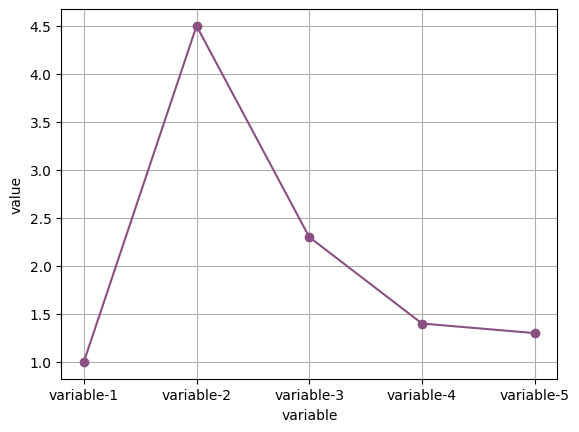

In [17]:
import matplotlib.pyplot as plt
import json

dictionary = json.load(open('/content/drive/MyDrive/Colab Notebooks/Cloud/3_1.json', 'r'))
xAxis = [key for key, value in dictionary.items()]
yAxis = [value for key, value in dictionary.items()]
plt.grid(True)

## LINE GRAPH ##
plt.plot(xAxis,yAxis, color='#8a5082', marker='o')
plt.xlabel('variable')
plt.ylabel('value')

plt.show()



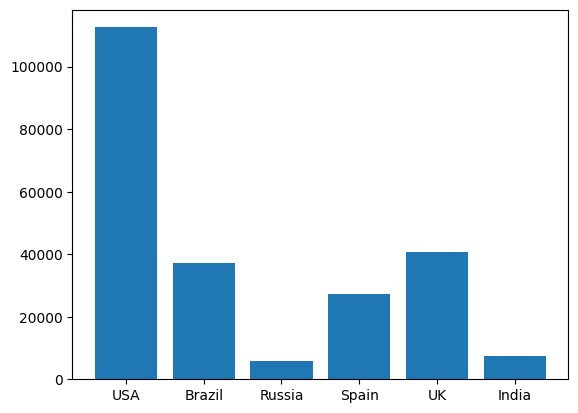

In [18]:
# Importing the matplotlib library
import matplotlib.pyplot as plt
# Categorical data: Country names
countries = ['USA', 'Brazil', 'Russia', 'Spain', 'UK', 'India']
# Integer value interms of death counts
totalDeaths = [112596, 37312, 5971, 27136, 40597, 7449]
# Passing the parameters to the bar function, this is the main function which creates the bar plot
plt.bar(countries, totalDeaths)
# Displaying the bar plot
plt.show()

In [19]:
import pandas as pd
a = [1, 7, 2]
myvar = pd.Series(a)
print(myvar)
print('-------------')
print(myvar[0])


0    1
1    7
2    2
dtype: int64
-------------
1


In [ ]:
import pandas as pd
calories = {"day1": 420, "day2": 380, "day3": 390}
myvar = pd.Series(calories)
print(myvar)


day1    420
day2    380
day3    390
dtype: int64


In [ ]:
import pandas as pd
data = {
"calories": [420, 380, 390],
"duration": [50, 40, 45]
}

myvar2 = pd.DataFrame(data, index = ["day1", "day2", "day3"])
print(myvar2)


      calories  duration
day1       420        50
day2       380        40
day3       390        45


In [ ]:
import pandas as pd
data = {
"calories": [420, 380, 390],
"duration": [50, 40, 45]
}
df = pd.DataFrame(data, index = ["day1", "day2", "day3"])
print(df)
print('----------------')
#refer to the named index:
print(df.loc["day2"])


      calories  duration
day1       420        50
day2       380        40
day3       390        45
----------------
calories    380
duration     40
Name: day2, dtype: int64


In [ ]:
import pandas
mydataset = {
 'cars': ["BMW", "Volvo", "Ford"],
 'passings': [3, 7, 2]
}
myvar = pandas.DataFrame(mydataset)
print(myvar)
myvar.to_json("3_2.json")


    cars  passings
0    BMW         3
1  Volvo         7
2   Ford         2


In [21]:
import json
data = {
  "cars": ["BMW", "Volvo", "Ford"],
  "passings": [3, 7, 2]
}

# with open("/content/drive/MyDrive/Colab Notebooks/Cloud/3_2.json", "w") as f:
#     json.dump(data, f, indent=4)

In [23]:
import pandas as pd
df2 = pd.read_json('/content/drive/My Drive/Colab Notebooks/Cloud/3_2.json')
print(df2.to_string())

    cars  passings
0    BMW         3
1  Volvo         7
2   Ford         2


In [24]:
import pandas as pd

data = {
  "Duration":{
    "0":60,
    "1":60,
    "2":60,
    "3":45,
    "4":45,
    "5":60
  },
  "Pulse":{
    "0":110,
    "1":117,
    "2":103,
    "3":109,
    "4":117,
    "5":102
  },
  "Maxpulse":{
    "0":130,
    "1":145,
    "2":135,
    "3":175,
    "4":148,
    "5":127
  },
  "Calories":{
    "0":409.1,
    "1":479.0,
    "2":340.0,
    "3":282.4,
    "4":406.0,
    "5":300.5
  }
}
with open("/content/drive/MyDrive/Colab Notebooks/Cloud/3_3.json", "w") as f:
    json.dump(data, f, indent=4)

df = pd.DataFrame(data)

print(df)


   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0
5        60    102       127     300.5


In [25]:
import pandas as pd
df2 = pd.read_json('/content/drive/My Drive/Colab Notebooks/Cloud/3_3.json')
print(df2.to_string())


   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0
5        60    102       127     300.5


In [26]:
import pandas as pd
mydataset = {
 'cars': ['BMW','Volvo', 'Ford'],
 'passings': [3,7,2]
}
df = pd.DataFrame(mydataset)
print(df)
print()
df = pd.DataFrame(mydataset)
print(df[df['passings']>5])
print()
print(df[(df['passings']>5) | (df['cars']=='Ford')])



    cars  passings
0    BMW         3
1  Volvo         7
2   Ford         2

    cars  passings
1  Volvo         7

    cars  passings
1  Volvo         7
2   Ford         2


In [27]:
df[df['passings']>5]

,cars,passings
1,Volvo,7


In [28]:
df[(df['passings']>5) | (df['cars']=='Ford')]


,cars,passings
1,Volvo,7
2,Ford,2


from matplotlib import pyplot as plt
_df_0['passings'].plot(kind='hist', bins=20, title='passings')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('cars').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['passings'].plot(kind='line', figsize=(8, 4), title='passings')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_3['cars'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_3, x='passings', y='cars', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [39]:
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3'
import requests
import pandas as pd
pd.set_option("display.max_columns", None)
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)

data_df = pd.DataFrame(data['result']['records'])
#יציג את 5 השורות הראשונות של הנתונים

data_df.head()

,_id,mispar_rechev,tozeret_cd,sug_degem,tozeret_nm,degem_cd,degem_nm,ramat_gimur,ramat_eivzur_betihuty,kvutzat_zihum,shnat_yitzur,degem_manoa,mivchan_acharon_dt,tokef_dt,baalut,misgeret,tzeva_cd,tzeva_rechev,zmig_kidmi,zmig_ahori,sug_delek_nm,horaat_rishum,moed_aliya_lakvish,kinuy_mishari
0,1,1000052,404,P,לקסוס יפן,19,USF40L-AEZGHW,PREMIUM,NaN,15.0,2013,1UR,2025-04-23,2026-04-20,פרטי,JTHBL46FX05120098,80,שנהב לבן,245/45R19,245/45R19,בנזין,130298.0,2013-4,LEXUS LS460
1,2,1000133,74,P,אלפא רומיאו,46,940FXB11,COMPETIZIONE,NaN,14.0,2015,940A2000,2025-03-12,2026-03-11,פרטי,ZAR94000007364894,50,אדום,205/55R16,205/55R16,בנזין,140002.0,2015-3,ALFA GIULIETTA
2,3,1000228,735,P,פורשה גרמניה,901,92A,,NaN,15.0,2016,CEYA,2025-03-13,2026-03-15,פרטי,WP1ZZZ92ZGKA09401,80,שנהב לבן,295/35/R21,295/35/R21,בנזין,160356.0,2016-3,CAYENNE
3,4,1000272,885,P,קיה קוריאה,561,JE5538,LX,NaN,15.0,2009,G6BA,2024-12-05,2025-11-07,פרטי,KNAKH813DA7688463,65,זהב,235/60R16,,בנזין,NaN,2009-11,SPORTAGE
4,5,1000314,940,P,רנו ספרד,181,BMOJOA,EX,NaN,NaN,2005,K4M,2025-11-03,2026-05-08,פרטי,VF1*BM0J0A*50086688*,56,אדום מטל,195/65 R15,195/65 R15,בנזין,NaN,None,MEGANE II


In [3]:
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3'
Tozeret = "" # @param [""]
Kinuy_Mishari = "" # @param [""]

import requests
import pandas as pd
pd.set_option("display.max_columns", None)
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)


# Create a DataFrame from the 'records' in the JSON response
data_df = pd.DataFrame(data['result']['records'])

# Set Tozeret with the 'tozeret_nm' column values
print (data_df['tozeret_nm'].tolist())




['לקסוס יפן', 'אלפא רומיאו', 'פורשה גרמניה', 'קיה קוריאה', 'רנו ספרד', 'פורשה גרמניה', 'טויוטה יפן', 'טויוטה יפן', 'טויוטה טורקיה', 'יונדאי קוריאה', 'טויוטה יפן', 'קיה קוריאה', 'טויוטה טורקיה', 'סוזוקי-יפן', 'פורשה גרמניה', 'אלפא רומיאו', 'מרצדס בנץ גרמנ', 'טויוטה יפן', 'מרצדס בנץ גרמנ', "טויוטה צ'כיה", 'טויוטה יפן', 'פיאט איטליה', 'קיה קוריאה', 'סוזוקי-יפן', 'יונדאי הודו', 'יונדאי קוריאה', "טויוטה צ'כיה", 'סוזוקי-יפן', 'קיה קוריאה', 'קיה סלובקיה', 'מרצדס בנץ גרמנ', 'יונדאי טורקיה', 'מרצדס בנץ גרמנ', 'מרצדס בנץ גרמנ', 'קיה קוריאה', 'טויוטה יפן', 'מרצדס בנץ גרמנ', 'שברולט ד.קוריא', 'מרצדס בנץ גרמנ', 'מרצדס בנץ גרמנ', 'פורד גרמניה', 'טויוטה יפן', 'מרצדס בנץ גרמנ', 'סוזוקי-יפן', 'מרצדס בנץ גרמנ', 'סוזוקי-יפן', 'קיה קוריאה', 'יונדאי קוריאה', 'יונדאי קוריאה', 'יונדאי קוריאה', 'מרצדס בנץ ארהב', 'טויוטה טורקיה', 'טויוטה יפן', 'שברולט ד.קוריא', 'טויוטה יפן', 'טויוטה יפן', 'טויוטה יפן', 'טויוטה יפן', 'סוזוקי-יפן', 'מרצדס בנץ גרמנ', 'מרצדס בנץ גרמנ', 'סוזוקי-יפן', 'טויוטה יפן', 'הונדה-יפן', 'פיא

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


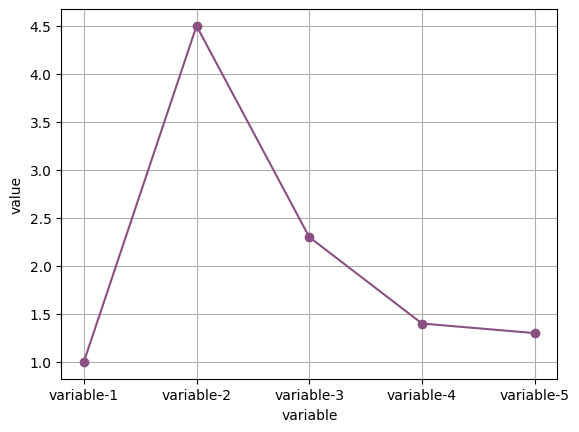

In [44]:
import matplotlib.pyplot as plt
import json
from google.colab import drive
drive.mount('/content/drive')
dictionary = json.load( open('/content/drive/My Drive/Colab Notebooks/Cloud/3_1.json' , 'r'))
xAxis = [key for key, value in dictionary.items()]
yAxis = [value for key, value in dictionary.items()]
plt.grid(True)
## LINE GRAPH ##
plt.plot(xAxis,yAxis, color= '#8a5082', marker='o')
plt.xlabel( 'variable')
plt.ylabel( 'value')
plt.show()

In [4]:
#CREATING WITH TABS

import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from plotly.offline import iplot
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  #seaborn for heatmap


# Create a simple DataFrame
# data = {
#     'Name': ['Alice', 'Bob', 'Charlie'],
#     'Age': [25, 30, 35],
#     'City': ['New York', 'Los Angeles', 'Chicago']
# }
# df = pd.DataFrame(data)
print(data_df)


         _id  mispar_rechev  tozeret_cd sug_degem      tozeret_nm  degem_cd  \
0          1        1000052         404         P       לקסוס יפן        19   
1          2        1000133          74         P     אלפא רומיאו        46   
2          3        1000228         735         P    פורשה גרמניה       901   
3          4        1000272         885         P      קיה קוריאה       561   
4          5        1000314         940         P        רנו ספרד       181   
...      ...            ...         ...       ...             ...       ...   
31995  31996        1045574         593         P  מרצדס בנץ גרמנ      1531   
31996  31997        1217132         845         P   יונדאי טורקיה        25   
31997  31998        1267333         940         P        רנו ספרד        29   
31998  31999        1229732         481         P   יונדאי קוריאה        96   
31999  32000        1217237         430         P   טויוטה אנגליה        18   

             degem_nm   ramat_gimur  ramat_eivzur_b

In [26]:
# Tab 1: Data Overview
tab1_content = widgets.Output()
with tab1_content:
    print("Data Overview:")
    display(data_df.describe())  # Summary statistics

# Tab 2: Raw Data
tab2_content = widgets.Output()
with tab2_content:
    print("Raw Data:")
    display(data_df)  # Full DataFrame

# Tab 3: Charts
tab3_content = widgets.Output()
with tab3_content:
    print("Charts:")
    plt.clf()  # Clear the current figure
    plt.figure(figsize=(10, 8))  # Increased figure size to accommodate labels
    side_length = 10
    xAxis =  set(data_df['shnat_yitzur'])
    xAxis = list(xAxis)
    yAxis = data_df['shnat_yitzur'].value_counts().tolist()
    plt.grid(True)
    ## LINE GRAPH ##
    plt.plot(xAxis,yAxis, color= '#8a5082', marker='o')
    plt.xlabel('Years')
    plt.ylabel('Created cars')
    plt.show()  # Add this to display the plot
    plt.close()  # Close the figure t free memory


In [27]:
# Create Tabs
tabs = widgets.Tab(children=[tab1_content, tab2_content,tab3_content])
tabs.set_title(0, 'Tab 1: Data Overview')
tabs.set_title(1, 'Tab 2: Raw Data')
tabs.set_title(2, 'Tab 3: Charts')



# Display Tabs
display(tabs)
